# PBC3.py test

In [1]:
%load_ext autoreload
%autoreload 2

from PBC3 import PBC3, PBC3Config
from PBC2_4 import PBC as PBC2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import os
import time
import io
from pbc3_debug_patch import install_debug_patch

PBC3 = install_debug_patch(PBC3)

from PBC3_animation import animate_pbc3

TEST_IMAGES_DIR = "test_images"
TEST_IMAGES = [os.path.join(TEST_IMAGES_DIR, f) for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

In [2]:
def show_debug_candidates(PBC3, debug_text, original_image=None, data=None):
    lines = [line.strip() for line in debug_text.strip().splitlines() if line.strip()]
    parsed = [PBC3.parse_debug_line(line) for line in lines]
    parsed = [(line, d) for line, d in zip(lines, parsed) if d]

    candidates = [(line, d) for line, d in parsed if d.get("kind") == "CANDIDATE"]
    selected = [(line, d) for line, d in parsed if d.get("kind") == "SELECTED"]

    if not candidates:
        print("No CANDIDATE lines found.")
        return

    selected_d = selected[-1][1] if selected else None

    for i, (line, d) in enumerate(candidates, 1):
        is_selected = False
        if selected_d is not None:
            is_selected = all(
                int(d.get(k, -999999)) == int(selected_d.get(k, -888888))
                for k in ("channel", "x", "y", "w", "h", "cell_size")
            )

        print(
            f"Candidate {i}/{len(candidates)}"
            + ("  <-- SELECTED" if is_selected else "")
            + f" | score={d.get('score')} reduction={d.get('reduction')} bits={d.get('bits')}"
        )

        PBC3.show_debug_line(
            line,
            original_image=original_image,
            data=data,
        )

    if selected:
        print("Selected patch:")
        selected_line = selected[-1][0]
        try:
            PBC3.show_debug_line(
                selected_line,
                original_image=original_image,
                data=data,
            )
        except Exception:
            print(selected_line)
    else:
        print("No SELECTED line found in pasted text.")


def efficiency_score(bpp, mse):
    return 1000 / (bpp * mse + 1e-9)
# Compare with JPEG with matching quality rate (match by file size) and also AVIF by the same metric
# quality helpers match quality levels to rough bpp averages, to help give a starting scale for the matching
def comparison_demo(img, res, search_count=8, verbose=False, show_png_too=False, figsize=(24, 6), tight_layout=True, suptitle_fontsize=16, suptitle_y=1.06):
    BPP_GUIDE = {
        "JPEG": [(1, 0.17), (5, 0.21), (10, 0.29), (20, 0.44), (40, 0.65), (60, 0.85), (80, 1.26), (95, 2.77)],
        "AVIF": [(0, 0.01), (2, 0.02), (5, 0.04), (10, 0.06), (20, 0.12), (40, 0.30), (60, 0.68), (80, 1.16), (95, 2.69)],
    }
    def guess_quality(fmt, target_bpp):
        """Inverse-interpolate the guideline table to pick a starting quality for `target_bpp`."""
        g = BPP_GUIDE[fmt]
        qs = [q for q, _ in g]
        bs = [b for _, b in g]
        if target_bpp <= bs[0]:
            return qs[0]
        if target_bpp >= bs[-1]:
            return qs[-1]
        for i in range(1, len(g)):
            if target_bpp <= bs[i]:
                f = (target_bpp - bs[i - 1]) / (bs[i] - bs[i - 1])
                return int(round(qs[i - 1] + f * (qs[i] - qs[i - 1])))
        return qs[-1]
    
    def match_quality(target_bpp, fmt, search_count=8, verbose=False):
        min_q = 0 if fmt == "AVIF" else 1
        max_q = 95

        def encode_at(q):
            buf = io.BytesIO()
            img.save(buf, format=fmt, quality=int(q))
            data = buf.getvalue()
            bpp = len(data) / (img.width * img.height)
            return q, bpp, data

        lo, hi = min_q, max_q
        best = None

        for _ in range(search_count):
            q = (lo + hi) // 2
            q, bpp, data = encode_at(q)

            err = abs(bpp - target_bpp)
            if best is None or err < best[0]:
                best = (err, q, bpp, data)

            if verbose:
                print(f"{fmt} quality {q} -> bpp {bpp:.5f}, target {target_bpp:.5f}")

            if target_bpp > 0 and err / target_bpp < 0.03:
                break

            if bpp > target_bpp:
                hi = q - 1
            else:
                lo = q + 1

            if lo > hi:
                break

        for q in range(max(min_q, best[1] - 3), min(max_q, best[1] + 3) + 1):
            q, bpp, data = encode_at(q)
            err = abs(bpp - target_bpp)
            if verbose:
                print(f"{fmt} refine quality {q} -> bpp {bpp:.5f}")
            if err < best[0]:
                best = (err, q, bpp, data)

        return best[1], best[2]
    # calculate pbc bpp by dividing the compressed size by the number of pixels in the image
    pbc_bpp = len(res.data) / (img.width * img.height)
    print(f"PBC3 bpp: {pbc_bpp:.4f}")
    plt.figure(figsize=figsize)
    plt.subplot(2, 3, 1)
    plt.title(f"Original Image\n{img.width*img.height*3/1024:.2f} KB")
    plt.imshow(img)
    plt.axis("off")
    # do the same for png
    if show_png_too:
        buf = io.BytesIO()
        t0 = time.time()
        img.save(buf, format="PNG")
        encode_time = time.time() - t0
        buf.seek(0)
        t0 = time.time()
        png_img = Image.open(buf)
        decode_time = time.time() - t0
        png_bpp = len(buf.getvalue()) / (img.width * img.height)
        print(f"PNG bpp: {png_bpp:.4f}")
        plt.subplot(2, 3, 2)
        plt.title(f"PNG ({encode_time:.2f}s - {decode_time:.2f}s)\nbpp: {png_bpp:.4f}, size: {len(buf.getvalue()) / 1024:.2f} KB\nMSE (lossless): {np.mean((np.array(img).astype(int) - np.array(png_img).astype(int)) ** 2):.1f}")
        plt.imshow(png_img)
        plt.axis("off")
    # match jpeg
    jpeg_quality, current_jpeg_bpp = match_quality(pbc_bpp, "JPEG", search_count=search_count, verbose=verbose)
    print(f"Matched JPEG quality: {jpeg_quality}, bpp: {current_jpeg_bpp:.4f}")
    avif_quality, current_avif_bpp = match_quality(pbc_bpp, "AVIF", search_count=search_count, verbose=verbose)
    print(f"Matched AVIF quality: {avif_quality}, bpp: {current_avif_bpp:.4f}")
    plt.subplot(2, 3, 2 + int(show_png_too))
    res24 = PBC2.compress(img)
    t0 = time.time()
    _ = PBC2.decompress(res24.data)
    decode_time = time.time() - t0
    plt.title(f"PBC2.4 ({res24.encode_seconds:.2f}s - {decode_time:.2f}s)\nbpp: {len(res24.data) / (img.width * img.height):.4f}, size: {len(res24.data) / 1024:.2f} KB\nMSE: {res24.mse:.1f}\nEfficiency Score: {efficiency_score(len(res24.data) / (img.width * img.height), res24.mse):.1f}")
    plt.imshow(res24.image)
    plt.axis("off")
    plt.subplot(2, 3, 3 + int(show_png_too))
    decoded = PBC3.decompress(res.data)
    plt.title(f"PBC3 ({res.encode_seconds:.2f}s - {decoded.encode_seconds:.2f}s)\nbpp: {pbc_bpp:.4f}, size: {len(res.data) / 1024:.2f} KB\nMSE: {res.mse:.1f}\nEfficiency Score: {efficiency_score(pbc_bpp, res.mse):.1f}")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(2, 3, 4 + int(show_png_too))
    buf = io.BytesIO()
    t0 = time.time()
    img.save(buf, format="JPEG", quality=jpeg_quality)
    encode_time = time.time() - t0
    buf.seek(0)
    t0 = time.time()
    jpeg_img = Image.open(buf)
    decode_time = time.time() - t0
    plt.imshow(jpeg_img)
    plt.title(f"JPEG ({encode_time:.2f}s - {decode_time:.2f}s)\nq: {jpeg_quality}, bpp: {current_jpeg_bpp:.4f}, size: {len(buf.getvalue()) / 1024:.2f} KB\nMSE: {np.mean((np.array(img).astype(int) - np.array(jpeg_img).astype(int)) ** 2):.1f}\nEfficiency Score: {efficiency_score(current_jpeg_bpp, np.mean((np.array(img).astype(int) - np.array(jpeg_img).astype(int)) ** 2)):.1f}")
    plt.axis("off")
    plt.subplot(2, 3, 5 + int(show_png_too))
    buf = io.BytesIO()
    t0 = time.time()
    img.save(buf, format="AVIF", quality=avif_quality)
    encode_time = time.time() - t0
    buf.seek(0)
    t0 = time.time()
    avif_img = Image.open(buf)
    decode_time = time.time() - t0
    plt.imshow(avif_img)
    plt.title(f"AVIF ({encode_time:.2f}s - {decode_time:.2f}s)\nq: {avif_quality}, bpp: {current_avif_bpp:.4f}, size: {len(buf.getvalue()) / 1024:.2f} KB\nMSE: {np.mean((np.array(img).astype(int) - np.array(avif_img).astype(int)) ** 2):.1f}\nEfficiency Score: {efficiency_score(current_avif_bpp, np.mean((np.array(img).astype(int) - np.array(avif_img).astype(int)) ** 2)):.1f}")
    plt.axis("off")
    plt.suptitle(f"Comparison of PBC3, PBC2.4, JPEG, and AVIF Compression for {img.width}x{img.height} Image", fontsize=suptitle_fontsize, y=suptitle_y)
    if tight_layout:
        plt.tight_layout()
    plt.show()

In [241]:
img = Image.open(TEST_IMAGES[1])
base = dict(patch_count=20, auto_downsample_init=True, search_q_start=0.4, search_q_end=0.1, init_search_depth=20)

cfgs = {
  "baseline":        dict(**base),
  "sum": dict(**base, channel_cycle="sum"),
  "off": dict(**base, channel_cycle="off"),
}
for name, kw in cfgs.items():
    r = PBC3.compress(img, **kw)
    print(f"{name:16} MSE={r.mse:7.2f}  KB={len(r.data)/1024:6.2f}  rate={r.compression_rate:5.2f}x  t={r.encode_seconds:5.2f}s  verify={r.verify()}")
    print(f"Efficiency Score: {efficiency_score(len(r.data) / (img.width * img.height), r.mse):.1f}")
    print()

[auto-init] channel 0: cell=4, bitcount=6
[auto-init] channel 1: cell=4, bitcount=5
[auto-init] channel 2: cell=4, bitcount=4
baseline         MSE= 437.32  KB= 30.58  rate=1150.31x  t= 1.65s  verify=True
Efficiency Score: 876.8

[auto-init] channel 0: cell=4, bitcount=6
[auto-init] channel 1: cell=4, bitcount=5
[auto-init] channel 2: cell=4, bitcount=4
sum              MSE= 437.32  KB= 30.58  rate=1150.31x  t= 1.57s  verify=True
Efficiency Score: 876.8

[auto-init] channel 0: cell=4, bitcount=6
[auto-init] channel 1: cell=4, bitcount=5
[auto-init] channel 2: cell=4, bitcount=4
off              MSE= 488.34  KB= 30.24  rate=1163.31x  t= 1.55s  verify=True
Efficiency Score: 794.1



[auto-init] channel 0: cell=2, bitcount=6
[auto-init] channel 1: cell=4, bitcount=5
[auto-init] channel 2: cell=4, bitcount=4
||||||||||||||||||||
MSE: 186.9056854248047, Compressed Size: 60.45 KB
Verification successful: Encoded and decoded images are identical.


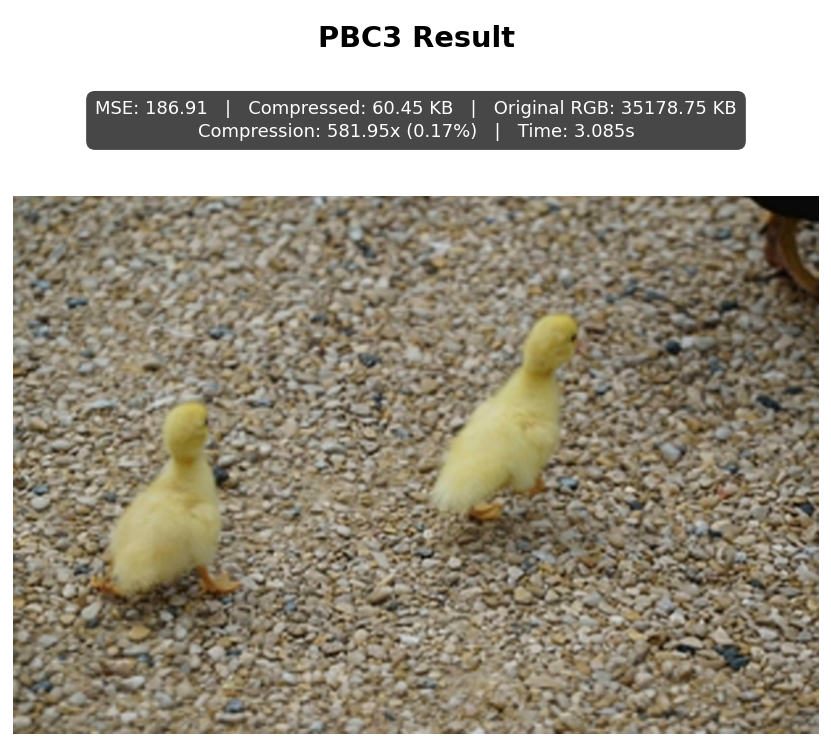

In [52]:
img = Image.open(TEST_IMAGES[1])

cfg = PBC3Config(
    patch_count=20,
    search_q_start=0.4,
    search_q_end=0.1,
    q_init=0.7,
    q_start=0.9,
    q_end=0.8,
    debug_print=True,
)

#cfg = PBC3Config(
#    patch_count=20,
#    debug_print=True,
#)

res = PBC3.compress(img, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    decoded = PBC3.decompress(res.data)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(float) - np.array(decoded.image).astype(float))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

In [156]:
animate_pbc3(
    res.data,
    output_path=f"{img.filename}_pbc.mp4",
    fps=3,
    separated_channels=True,
    show_errors=True,
    original_image=img,
    fallback_to_gif=False,
)

[rawvideo @ 0x12ef15b40] Stream #0: not enough frames to estimate rate; consider increasing probesize
[vost#0:0/libx264 @ 0x139805180] Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


'test_images/eiffel.png_pbc.mp4'

PBC3 bpp: 0.0051
PNG bpp: 1.2238
Matched JPEG quality: 1, bpp: 0.0183
Matched AVIF quality: 9, bpp: 0.0051


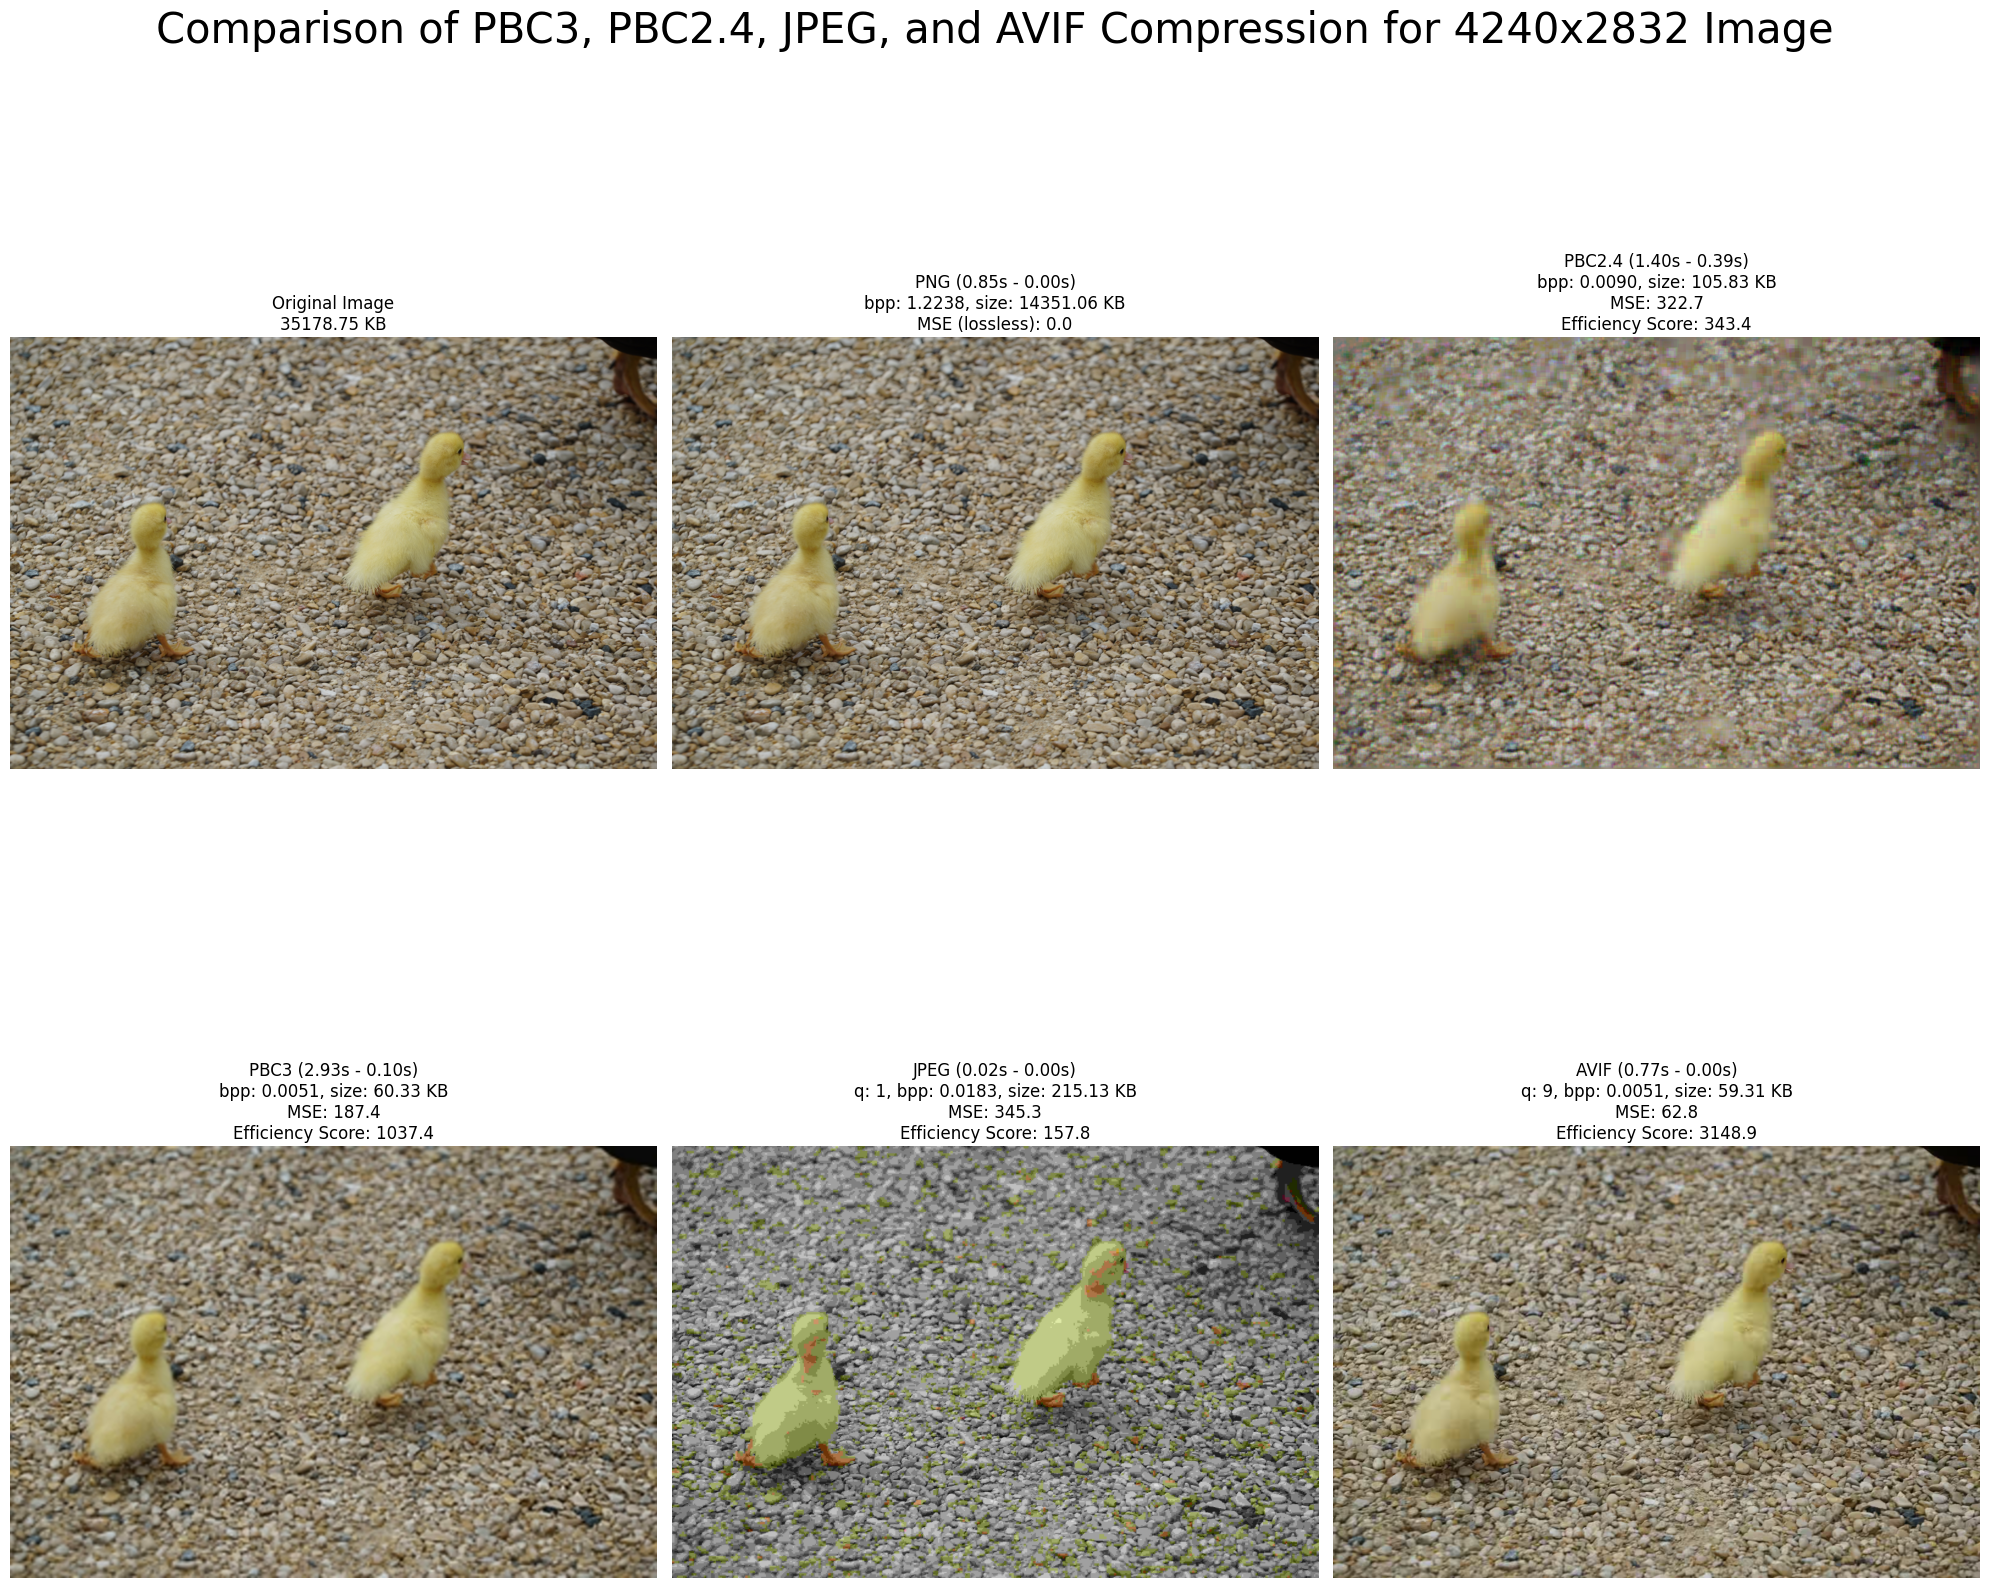

In [46]:
comparison_demo(img, res, search_count=5, show_png_too=True, figsize=(20, 20), tight_layout=True, suptitle_fontsize=30, suptitle_y=0.96)

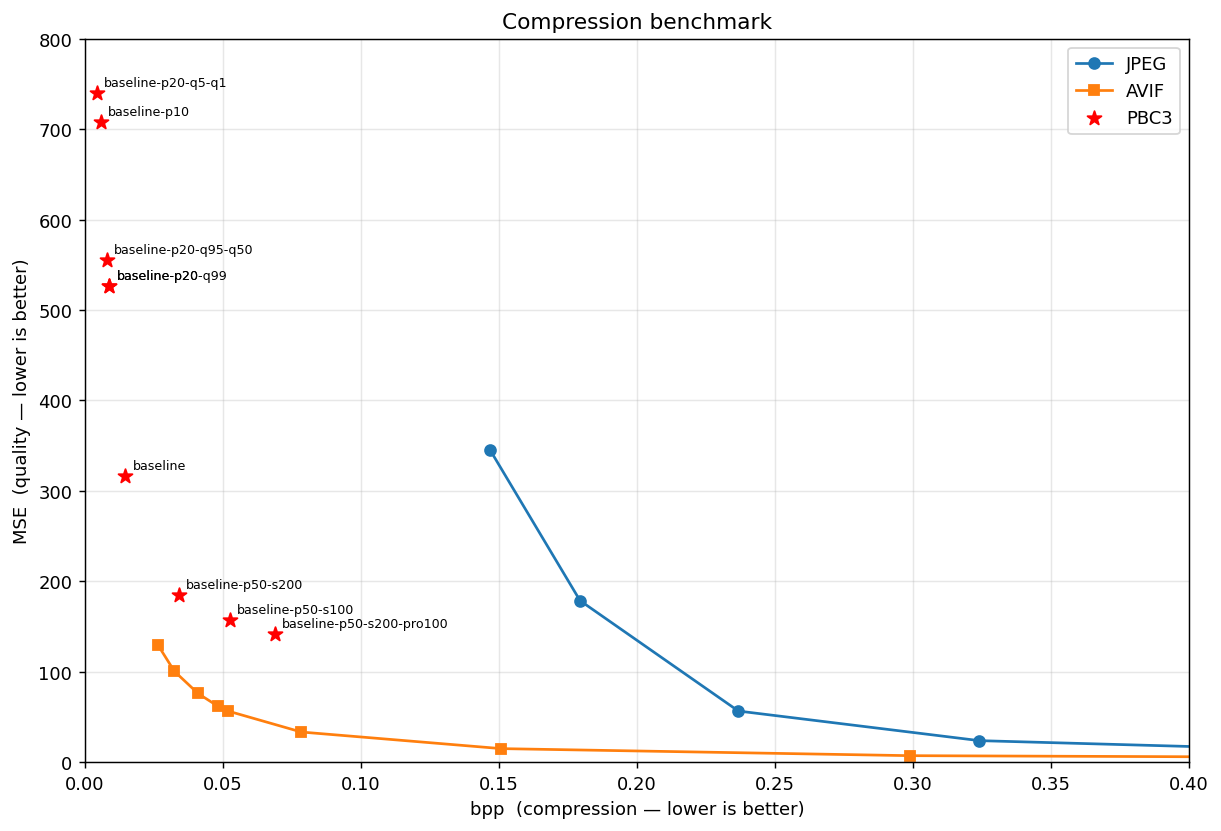

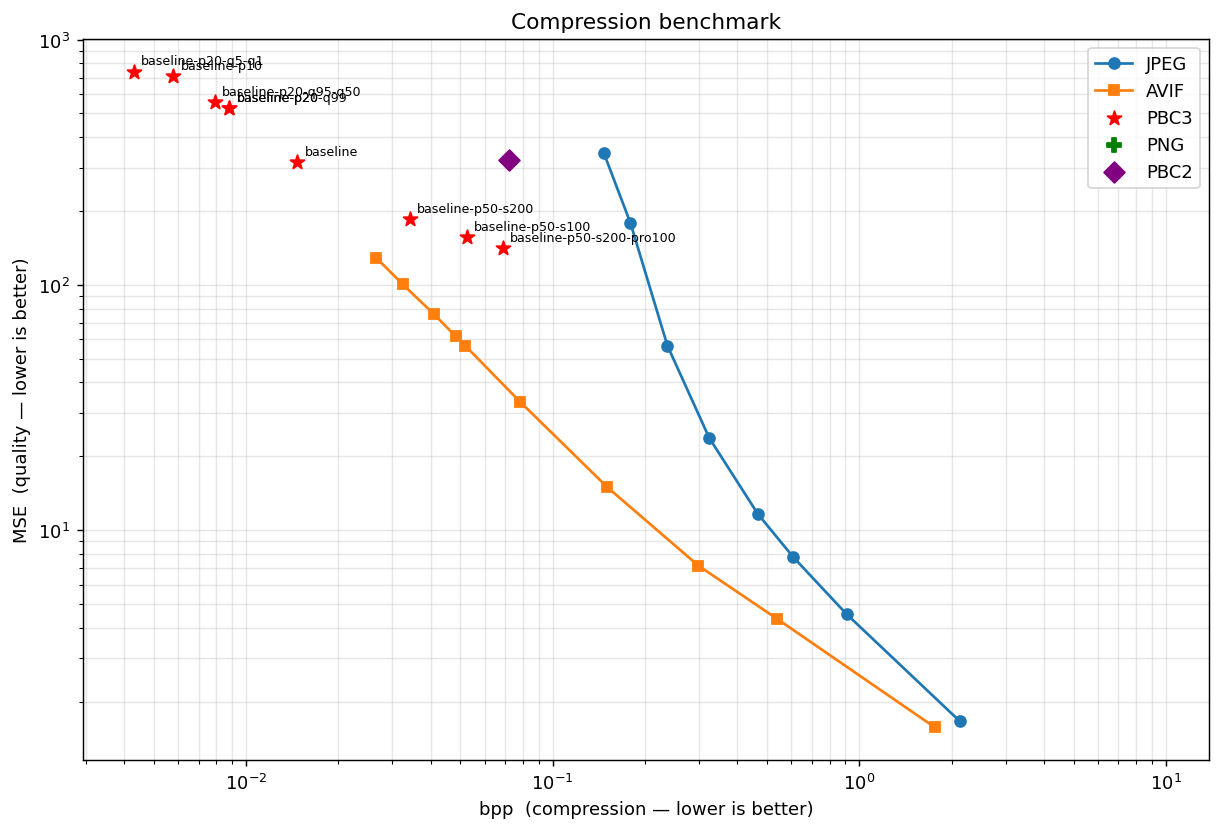

In [118]:
from benchmark_plot import plot_benchmark
bench_name = "bench_ducklings"


# only the lossy codecs, zoomed to a useful range
plot_benchmark(f"{bench_name}_summary.csv", include=("JPEG","AVIF","PBC3"),
               xlim=(0,0.4), ylim=(0,800), yscale="linear")#, out_path="zoom.png")

# everything, log-log
plot_benchmark(f"{bench_name}_summary.csv", xscale="log", yscale="log")